# Importing required libraries

In [110]:
import numpy as np 
import seaborn as sns 
import pandas as pd 
import matplotlib.pyplot as plt
import warnings 

warnings.filterwarnings('ignore')

# Setting the seaborn background theme

In [111]:
sns.set_theme()
sns.set_style("whitegrid")
sns.set_context("talk")
sns.set_palette("Set2")

# Loading dataset

In [112]:
data = pd.read_csv('heart.csv')

# EDA (Exploratory Data Analysis)

In [113]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


**Data shape size and info**

In [114]:
data.shape

(918, 12)

In [115]:
data.size

11016

In [116]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [117]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [118]:
data.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [119]:
cat_cols = data[['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope','FastingBS']]

In [120]:
for col in cat_cols :
    print(data[col].value_counts())
    print("=========================")

Sex
M    725
F    193
Name: count, dtype: int64
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64
FastingBS
0    704
1    214
Name: count, dtype: int64


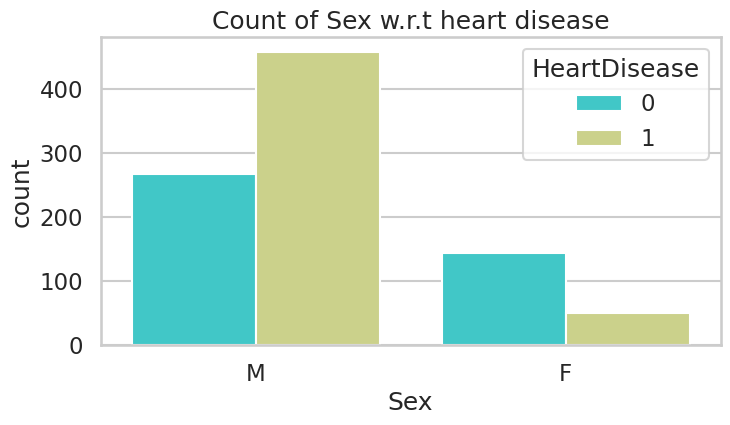

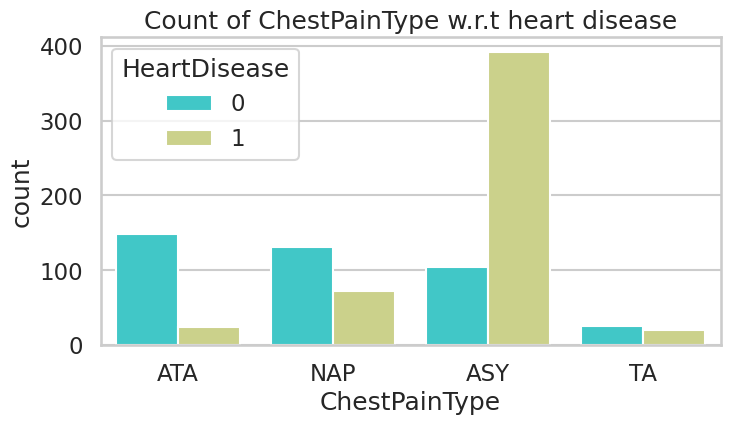

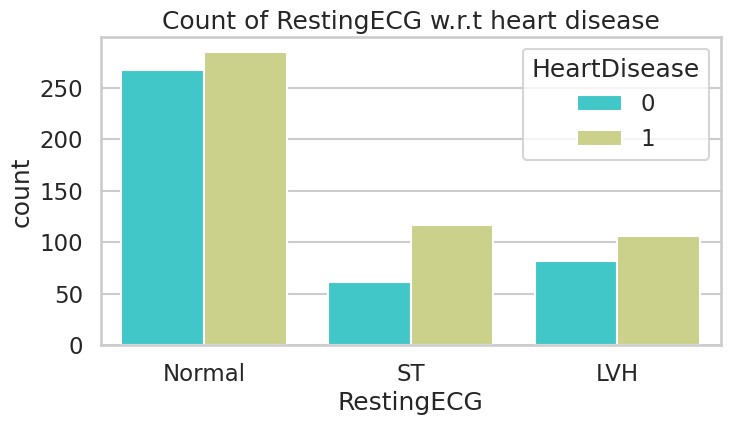

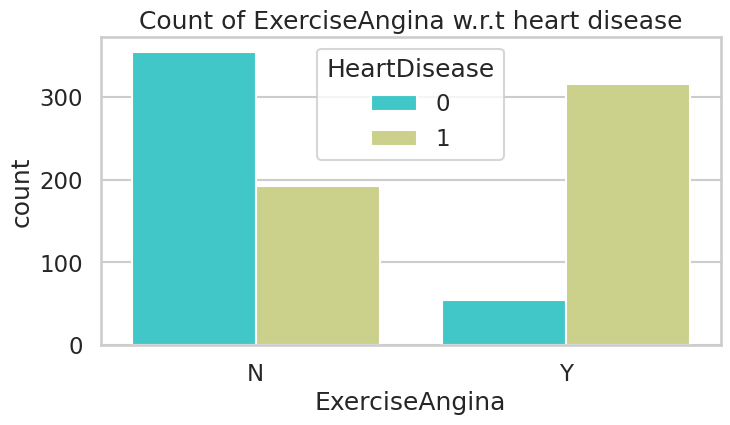

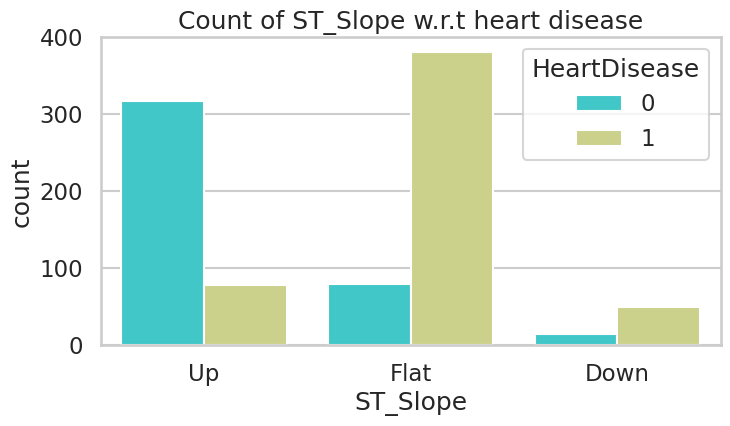

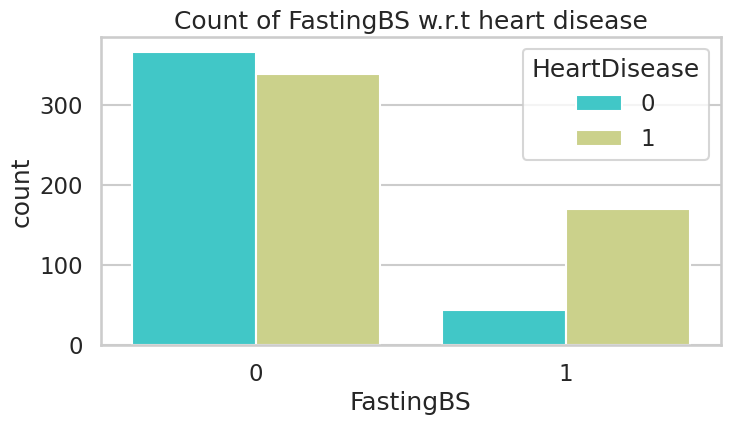

In [121]:
for col in cat_cols:
    plt.figure(figsize = (8,4))
    sns.countplot(x = data[col], hue= data['HeartDisease'], palette='rainbow')
    plt.title(f"Count of {col} w.r.t heart disease")
    plt.show()
    

In [122]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


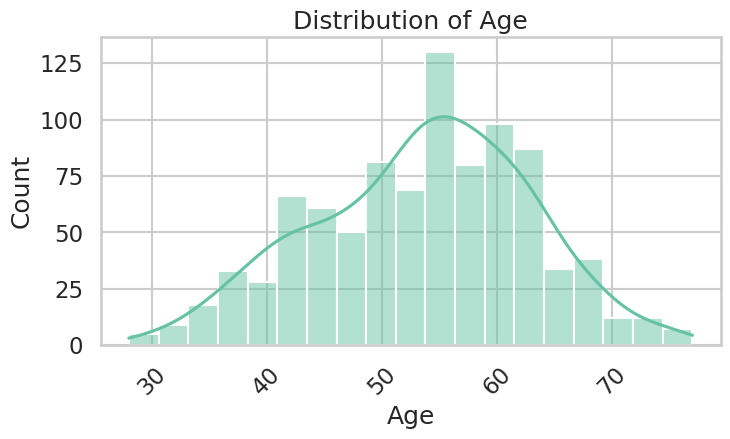

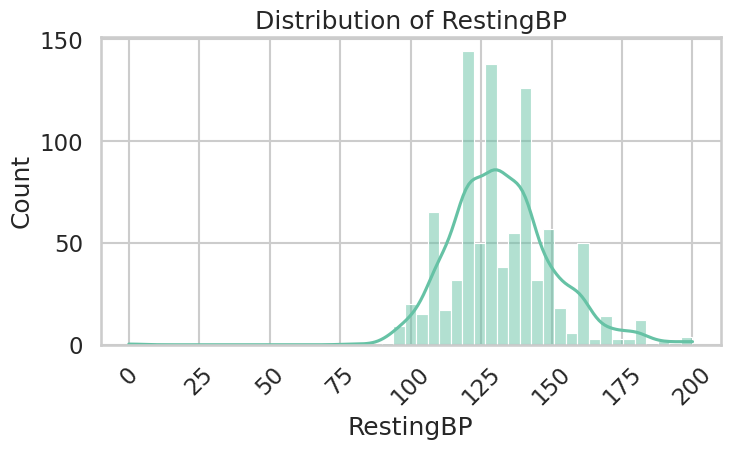

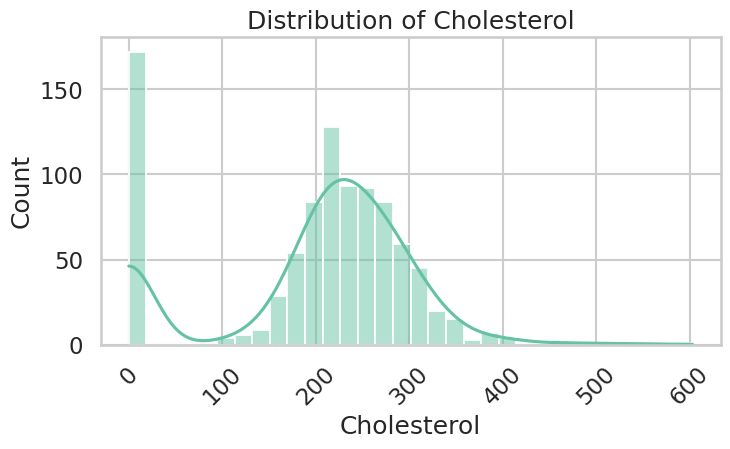

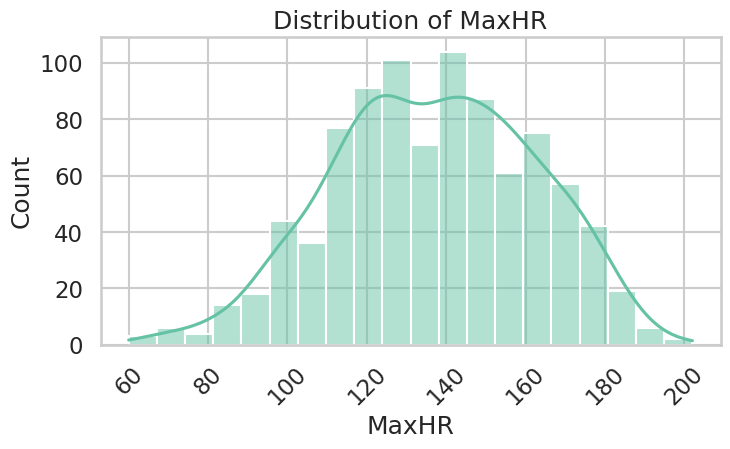

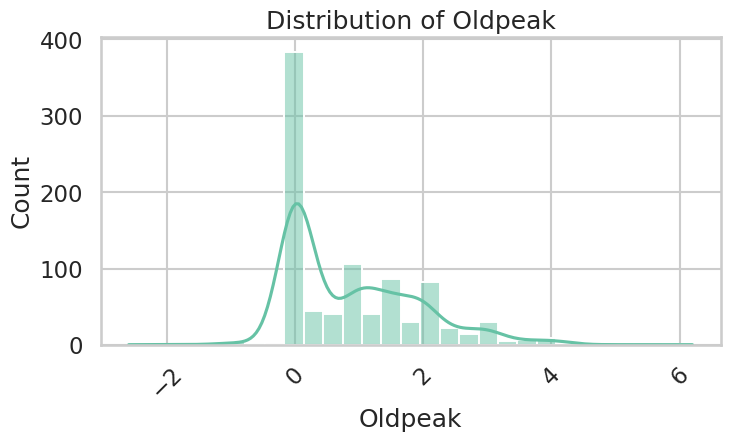

In [123]:
numeric_cols = data[['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']]
for col in numeric_cols:
    plt.figure(figsize = (8,4))
    sns.histplot(data[col], kde = True )
    plt.xticks(rotation = 45)
    plt.title(f"Distribution of {col}")

# Filling impossible cholestrol and Resting Bp like 0 with mean


In [124]:
data['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [125]:
data['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
174      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64

In [126]:
ch_mean = data.loc[data['Cholesterol'] != 0, 'Cholesterol'].mean()

In [127]:
data['Cholesterol'] = data['Cholesterol'].replace(0, ch_mean)
data['Cholesterol'] = data['Cholesterol'].round(2)

In [128]:
bp_mean = data.loc[data['RestingBP'] != 0, 'RestingBP'].mean()
data['RestingBP'] = data['RestingBP'].replace(0, bp_mean)
data['RestingBP'] = data['RestingBP'].round(2)


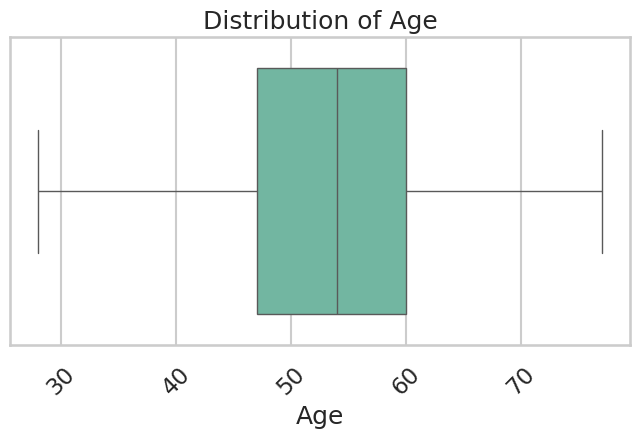

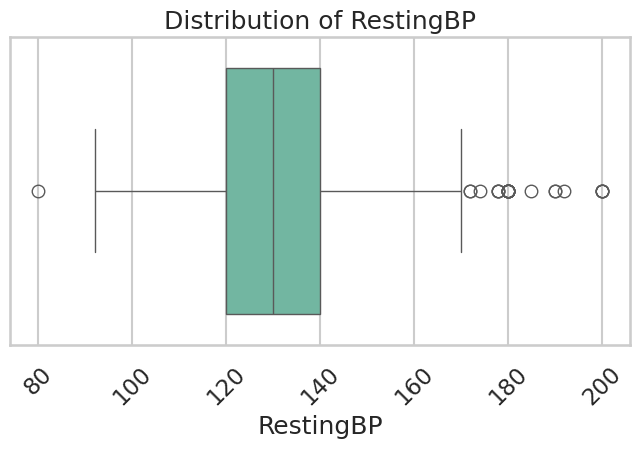

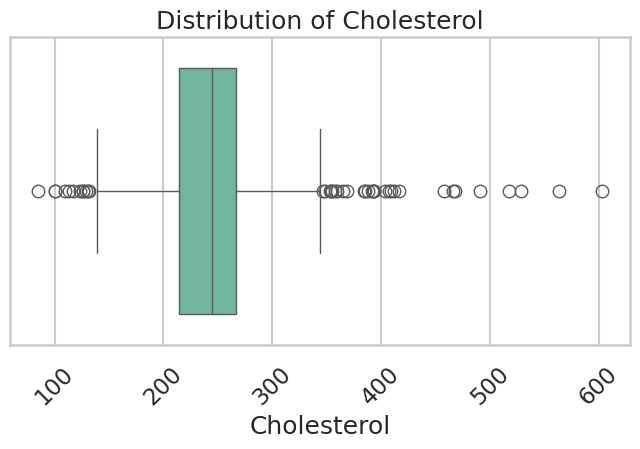

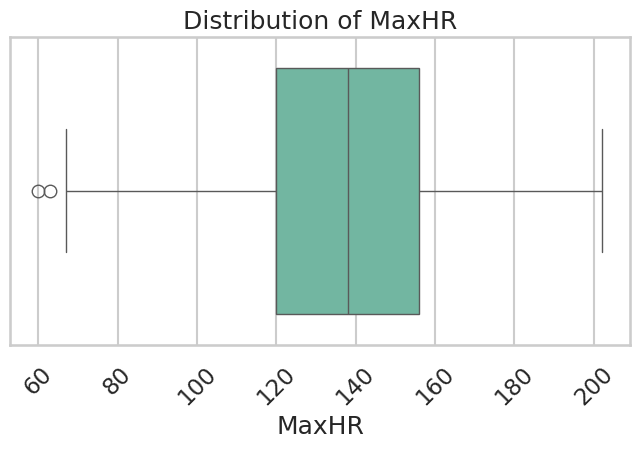

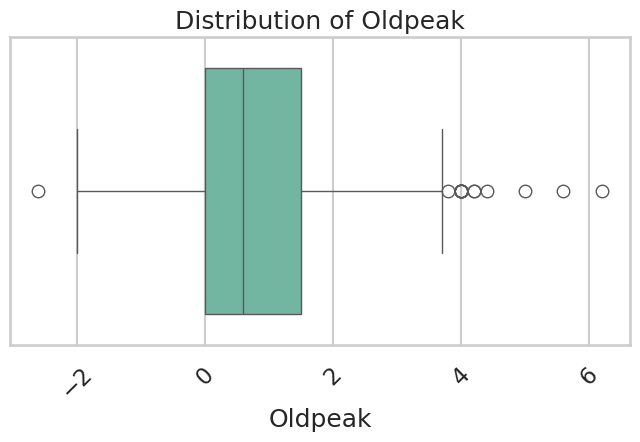

In [129]:
for col in numeric_cols:
    plt.figure(figsize = (8,4))
    sns.boxplot(x=data[col])
    plt.xticks(rotation = 45)
    plt.title(f"Distribution of {col}")
    plt.show()

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

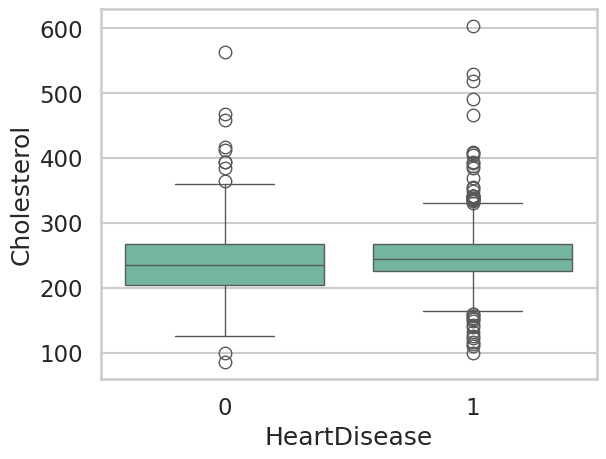

In [130]:
sns.boxplot(x=data['HeartDisease'],y = data['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

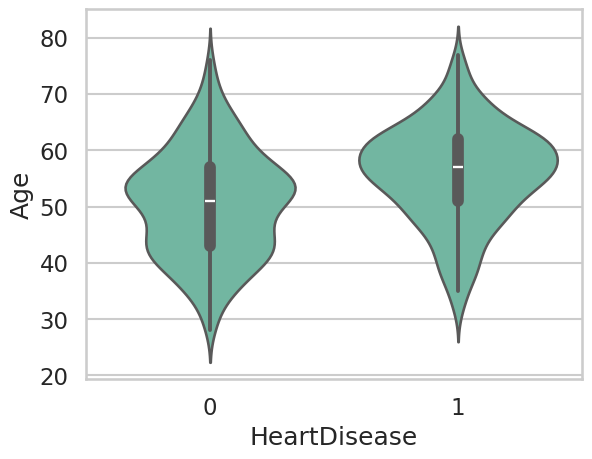

In [131]:
sns.violinplot(x=data['HeartDisease'],y = data['Age'])

In [132]:
for col in cat_cols:
    print(data.groupby(col)['HeartDisease'].value_counts())
    print("===================================")

Sex  HeartDisease
F    0               143
     1                50
M    1               458
     0               267
Name: count, dtype: int64
ChestPainType  HeartDisease
ASY            1               392
               0               104
ATA            0               149
               1                24
NAP            0               131
               1                72
TA             0                26
               1                20
Name: count, dtype: int64
RestingECG  HeartDisease
LVH         1               106
            0                82
Normal      1               285
            0               267
ST          1               117
            0                61
Name: count, dtype: int64
ExerciseAngina  HeartDisease
N               0               355
                1               192
Y               1               316
                0                55
Name: count, dtype: int64
ST_Slope  HeartDisease
Down      1                49
          0                

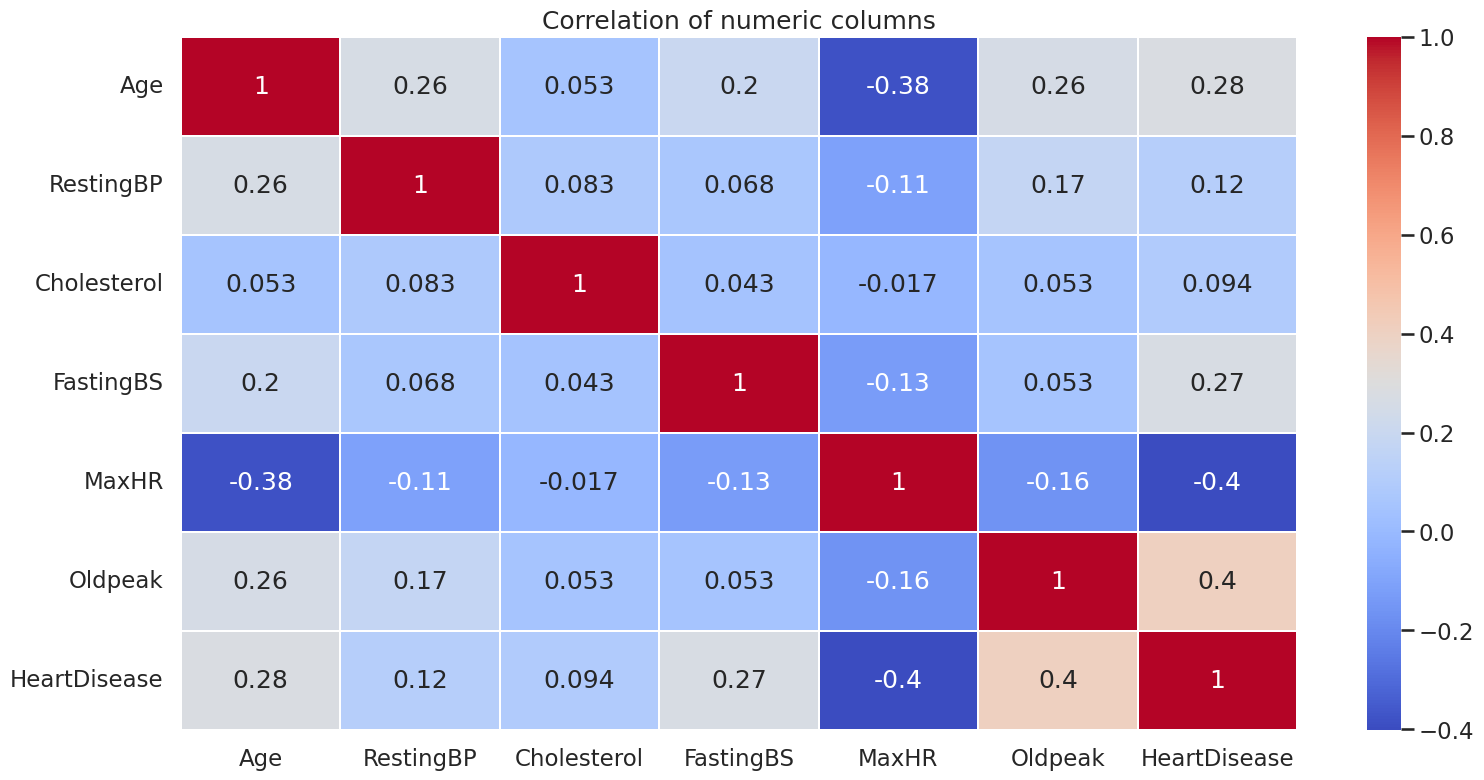

In [133]:
plt.figure(figsize= (18,9))
sns.heatmap(data.corr(numeric_only= True), annot=True, cmap='coolwarm', linewidths=0.25)
plt.title("Correlation of numeric columns")
plt.show()

# Data Cleaning & Pre-processing 

In [134]:
data_cleaned = data.copy()

In [135]:
data_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 97.6 KB


In [136]:
data_cleaned.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [137]:
data_cleaned.columns = data_cleaned.columns.str.lower().str.replace(' ','_')

In [138]:
data_cleaned.head()

,age,sex,chestpaintype,restingbp,cholesterol,fastingbs,restingecg,maxhr,exerciseangina,oldpeak,st_slope,heartdisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [139]:
data_cleaned.drop_duplicates(inplace=True)

In [140]:
data_cleaned.dtypes

age                 int64
sex                   str
chestpaintype         str
restingbp         float64
cholesterol       float64
fastingbs           int64
restingecg            str
maxhr               int64
exerciseangina        str
oldpeak           float64
st_slope              str
heartdisease        int64
dtype: object

In [141]:
data_cleaned['sex'].value_counts()

sex
M    725
F    193
Name: count, dtype: int64

In [142]:
data_cleaned['exerciseangina'].value_counts()

exerciseangina
N    547
Y    371
Name: count, dtype: int64

In [143]:
data_cleaned['sex'] = data_cleaned['sex'].map({
    'M' : 1,
    'F' : 0
}, inplace = True)

data_cleaned['exerciseangina'] = data_cleaned['exerciseangina'].map({
    'N' : 0,
    'Y' : 1
}, inplace = True)

data_cleaned.rename(columns={'sex': 'is_male', 'exerciseangina' : 'exercise_angina'}, inplace = True)

In [144]:
data_cleaned = pd.get_dummies(data_cleaned,columns= ['chestpaintype', 'restingecg', 'st_slope'], prefix=['chestpaintype', 'restingecg', 'st_slope'], dtype = int)

In [145]:
data_cleaned.head()

,age,is_male,restingbp,cholesterol,fastingbs,maxhr,exercise_angina,oldpeak,heartdisease,chestpaintype_ASY,chestpaintype_ATA,chestpaintype_NAP,chestpaintype_TA,restingecg_LVH,restingecg_Normal,restingecg_ST,st_slope_Down,st_slope_Flat,st_slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160.0,180.0,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130.0,283.0,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150.0,195.0,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1


In [146]:
X = data_cleaned.drop(columns='heartdisease')
y = data_cleaned['heartdisease']

# Feature Selection testing

**Pearsonr correlation**

In [147]:
from scipy.stats import pearsonr

targeted_cols = ['age', 'is_male', 'restingbp', 'cholesterol', 'fastingbs', 'maxhr',
       'exercise_angina', 'oldpeak', 'chestpaintype_ASY',
       'chestpaintype_ATA', 'chestpaintype_NAP', 'chestpaintype_TA',
       'restingecg_LVH', 'restingecg_Normal', 'restingecg_ST', 'st_slope_Down',
       'st_slope_Flat', 'st_slope_Up']

correlation = {
    feature : pearsonr(X[feature], y)[0] 
    for feature in targeted_cols
}

correlation_df = pd.DataFrame(list(correlation.items()), columns=['Feature', 'Correlation with heartdisease'])
correlation_df.sort_values(by='Correlation with heartdisease', ascending=False)

,Feature,Correlation with heartdisease
16,st_slope_Flat,0.554134
8,chestpaintype_ASY,0.516716
6,exercise_angina,0.494282
7,oldpeak,0.403951
1,is_male,0.305445
0,age,0.282039
4,fastingbs,0.267291
15,st_slope_Down,0.122527
2,restingbp,0.117938
14,restingecg_ST,0.102527


**Chi-squared Test**

In [148]:
cat_features = [ 'is_male', 'fastingbs', 
       'exercise_angina',  'chestpaintype_ASY',
       'chestpaintype_ATA', 'chestpaintype_NAP', 'chestpaintype_TA',
       'restingecg_LVH', 'restingecg_Normal', 'restingecg_ST', 'st_slope_Down',
       'st_slope_Flat', 'st_slope_Up']


from scipy.stats import chi2_contingency

alpha = 0.05
chi2results = {}

for col in cat_features:
    contingency_table = pd.crosstab(X[col], y)
    
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
    
    decision = 'Reject Null (keep feature)' if p_val <= alpha else 'Accept Null (Reject feature)'
    
    chi2results[col] = {
        'chi2_stat' : chi2_stat,
        'p_value' : p_val ,
        'Decision' : decision
    }
    
    
chi2results_df = pd.DataFrame(chi2results).T
chi2results_df.sort_values(by='p_value', ascending=True)

,chi2_stat,p_value,Decision
st_slope_Up,352.823905,0.0,Reject Null (keep feature)
st_slope_Flat,279.659914,0.0,Reject Null (keep feature)
chestpaintype_ASY,243.021138,0.0,Reject Null (keep feature)
exercise_angina,222.259383,0.0,Reject Null (keep feature)
chestpaintype_ATA,146.236323,0.0,Reject Null (keep feature)
is_male,84.145101,0.0,Reject Null (keep feature)
fastingbs,64.320679,0.0,Reject Null (keep feature)
chestpaintype_NAP,40.608711,0.0,Reject Null (keep feature)
st_slope_Down,12.824125,0.000342,Reject Null (keep feature)
restingecg_ST,9.135266,0.002507,Reject Null (keep feature)


**Mutual-info-classifier**

In [149]:
column = ['age', 'is_male', 'restingbp', 'cholesterol', 'fastingbs', 'maxhr',
       'exercise_angina', 'oldpeak', 'chestpaintype_ASY', 'chestpaintype_ATA',
       'chestpaintype_NAP', 'chestpaintype_TA', 'restingecg_LVH',
       'restingecg_Normal', 'restingecg_ST', 'st_slope_Down', 'st_slope_Flat',
       'st_slope_Up']

from sklearn.feature_selection import mutual_info_classif

discrete_features = [
    col.startswith(("chestpaintype_", "restingecg_", "st_slope_"))
    or col in ["is_male", "fastingbs", "exercise_angina"]
    for col in column
]

MI_score = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_features,
    random_state=42
)

MI_table = {}

for i, col in enumerate(column):
    MI_table[col] = {
        "MI_score": MI_score[i]
    }

MI_df = pd.DataFrame(MI_table).T

MI_df.sort_values(
    by="MI_score",
    ascending=False
)



,MI_score
st_slope_Up,0.206974
st_slope_Flat,0.163076
chestpaintype_ASY,0.139650
exercise_angina,0.131680
oldpeak,0.097693
chestpaintype_ATA,0.085956
maxhr,0.082228
cholesterol,0.065946
age,0.055928
is_male,0.047477


# Test-Train Split

In [150]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [151]:
X_train

,age,is_male,restingbp,cholesterol,fastingbs,maxhr,exercise_angina,oldpeak,chestpaintype_ASY,chestpaintype_ATA,chestpaintype_NAP,chestpaintype_TA,restingecg_LVH,restingecg_Normal,restingecg_ST,st_slope_Down,st_slope_Flat,st_slope_Up
585,57,1,180.0,285.00,1,120,0,0.8,0,1,0,0,0,0,1,0,1,0
169,58,1,140.0,179.00,0,160,0,0.0,0,0,1,0,0,1,0,0,0,1
602,61,1,120.0,337.00,0,98,1,0.0,0,0,1,0,0,1,0,0,1,0
140,52,1,160.0,331.00,0,94,1,2.5,1,0,0,0,0,1,0,0,1,0
173,49,1,140.0,187.00,0,172,0,0.0,0,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,48,0,120.0,254.00,0,110,0,0.0,1,0,0,0,0,0,1,0,0,1
270,45,1,120.0,225.00,0,140,0,0.0,1,0,0,0,0,1,0,0,0,1
860,60,1,130.0,253.00,0,144,1,1.4,1,0,0,0,0,1,0,0,0,1
435,60,1,152.0,244.64,0,118,1,0.0,1,0,0,0,0,0,1,0,0,1


In [152]:
y_train

585    1
169    0
602    1
140    1
173    0
      ..
106    0
270    0
860    1
435    0
102    1
Name: heartdisease, Length: 615, dtype: int64

# Feature Scalling and Selection

In [154]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

columns_to_scale = [
    'age',
    'restingbp',
    'cholesterol',
    'maxhr',
    'oldpeak'
]

X_train[columns_to_scale] = scaler.fit_transform(
    X_train[columns_to_scale]
)

X_test[columns_to_scale] = scaler.transform(
    X_test[columns_to_scale]
)

In [155]:
X_train.head()

,age,is_male,restingbp,cholesterol,fastingbs,maxhr,exercise_angina,oldpeak,chestpaintype_ASY,chestpaintype_ATA,chestpaintype_NAP,chestpaintype_TA,restingecg_LVH,restingecg_Normal,restingecg_ST,st_slope_Down,st_slope_Flat,st_slope_Up
585,0.355153,1,2.625139,0.793876,1,-0.676038,0,-0.106065,0,1,0,0,0,0,1,0,1,0
169,0.459560,1,0.379516,-1.296963,0,0.941561,0,-0.826835,0,0,1,0,0,1,0,0,0,1
602,0.772781,1,-0.743296,1.819571,0,-1.565717,1,-0.826835,0,0,1,0,0,1,0,0,1,0
140,-0.166881,1,1.502327,1.701221,0,-1.727477,1,1.425573,1,0,0,0,0,1,0,0,1,0
173,-0.480102,1,0.379516,-1.139164,0,1.426841,0,-0.826835,0,0,1,0,0,1,0,0,0,1


In [156]:
X_test.head()

,age,is_male,restingbp,cholesterol,fastingbs,maxhr,exercise_angina,oldpeak,chestpaintype_ASY,chestpaintype_ATA,chestpaintype_NAP,chestpaintype_TA,restingecg_LVH,restingecg_Normal,restingecg_ST,st_slope_Down,st_slope_Flat,st_slope_Up
668,0.981595,0,0.379516,-0.981365,0,1.709920,0,-0.826835,0,1,0,0,0,1,0,0,0,1
30,-0.062474,1,0.660219,5.389777,0,-0.271638,0,-0.826835,0,0,1,0,0,1,0,0,1,0
377,1.190409,1,1.502327,-0.002221,1,-0.595158,0,0.254321,1,0,0,0,0,0,1,0,1,0
535,0.250746,1,-0.181890,-0.002221,0,-0.595158,1,0.074128,1,0,0,0,1,0,0,0,1,0
807,0.041933,1,-1.416983,1.267274,0,0.779801,0,-0.826835,0,1,0,0,0,1,0,0,0,1


# Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
models = {
    "LogisticRegression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "NB" : GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(max_depth=3),
    "SVM": SVC(kernel='rbf'),
    "RandomForest": RandomForestClassifier(n_estimators=300)
}

results = {}

In [ ]:
for name,model in models.items() :
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = pred
    

In [ ]:
for model, result in results.items():
    print(model ,":", result)

LogisticRegression : [0 1 1 1 0 1 1 0 1 1 1 0 1 0 1 1 0 1 1 0 0 1 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1
 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 1 1 1 0 0 1 0
 0 1 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 1 0 1 0 1 1 0 1 1 0 0 1 0 0 1 0 1
 1 0 0 1 0 1 0 1 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 1 0 1 1 0 1 0 0 1 1 1 1 1 0
 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 1 0
 0 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 1 0 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 0 1
 1 0 1 0 1 1 0 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 1 1 0 0 1 1 0 1 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 0 0 0 1 0 0 1 0
 1 0 0 0 0 0 1]
KNN : [0 1 1 1 0 1 1 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 0 1 0 0 1 0 0 1 1 1 1
 0 1 1 1 1 1 0 0 1 1 1 1 0 0 0 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 1 1 1 0 0 0 0
 0 1 0 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 0 1 0 1 1 0 1 1 0 0 1 0 0 1 0 1
 1 0 0 1 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0
 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 

# Models Evaluation

In [ ]:
evaluation = {}

for model, result in results.items():

    accuracy = accuracy_score(y_test, result)
    precision = precision_score(y_test, result)
    recall = recall_score(y_test, result)
    f1 = f1_score(y_test, result)

    evaluation[model] = [
        round(accuracy,2),
        round(precision,2),
        round(recall,2),
        round(f1,2)
    ]

evaluation_df = pd.DataFrame(
    evaluation,
    index=["Accuracy", "Precision", "Recall", "F1 Score"]
)

evaluation_df

,LogisticRegression,KNN,NB,DecisionTree,SVM,RandomForest
Accuracy,0.86,0.85,0.84,0.83,0.85,0.87
Precision,0.93,0.91,0.92,0.90,0.90,0.93
Recall,0.83,0.83,0.81,0.81,0.84,0.84
F1 Score,0.87,0.87,0.86,0.85,0.87,0.88


# Saving SVM model file 

In [158]:
import joblib as jl
jl.dump(models['SVM'], 'model.pkl')
jl.dump(scaler, 'scalar.pkl')
jl.dump(X.columns, 'columns.pkl')
jl.dump(columns_to_scale,'columns_to_scale.pkl')

['columns_to_scale.pkl']